In [1]:
import torch
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import glob
from collections import OrderedDict
from ReportPretraining import ReportClassification
from src.layers.transformer.ATAT import LightCurveTransformer,TabularTransformer



from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
import matplotlib.pyplot as plt
import numpy as np



In [2]:
DATASET  ='test'
DEVICE = 'cuda:0'
PATH_1 ='/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/DEBUG_ZTF/LC/class_ZTF_debug_v0_mean_test_zerotokens_window_factor_0/'
PATH_2 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/NEW_OPTIM/LC/class_test_v12_0/'

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY

FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'

In [3]:
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier
from src.layers.transformer.ATAT import LightCurveTransformer


True False False
Using checkpoint 2256.ckpt
Using checkpoint 2256.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


100%|██████████| 477/477 [00:04<00:00, 104.08it/s]


                precision    recall  f1-score   support

           AGN     0.5293    0.4388    0.4798       556
           QSO     0.6174    0.7702    0.6854       570
            EA     0.8314    0.7702    0.7996       570
           YSO     0.6229    0.5359    0.5762       487
          SNIa     0.7332    0.6969    0.7146       485
       CV/Nova     0.7143    0.6406    0.6755       320
          RRLc     0.6810    0.7128    0.6965       578
         RSCVn     0.5000    0.4887    0.4943       444
        Blazar     0.4888    0.4037    0.4422       270
          SNII     0.6285    0.5803    0.6034       274
         EB/EW     0.6449    0.7353    0.6871       578
           LPV     0.8409    0.9293    0.8829       580
           CEP     0.7084    0.6095    0.6553       566
         RRLab     0.7334    0.7612    0.7470       582
Periodic-Other     0.3711    0.2458    0.2957       240
          DSCT     0.4181    0.5625    0.4797       304
         SNIbc     0.2556    0.3953    0.3105  

<Axes: title={'center': 'Lightcurve Classification | Dataset: test | macro f1: 0.4979'}, xlabel='Predicted label', ylabel='True label'>

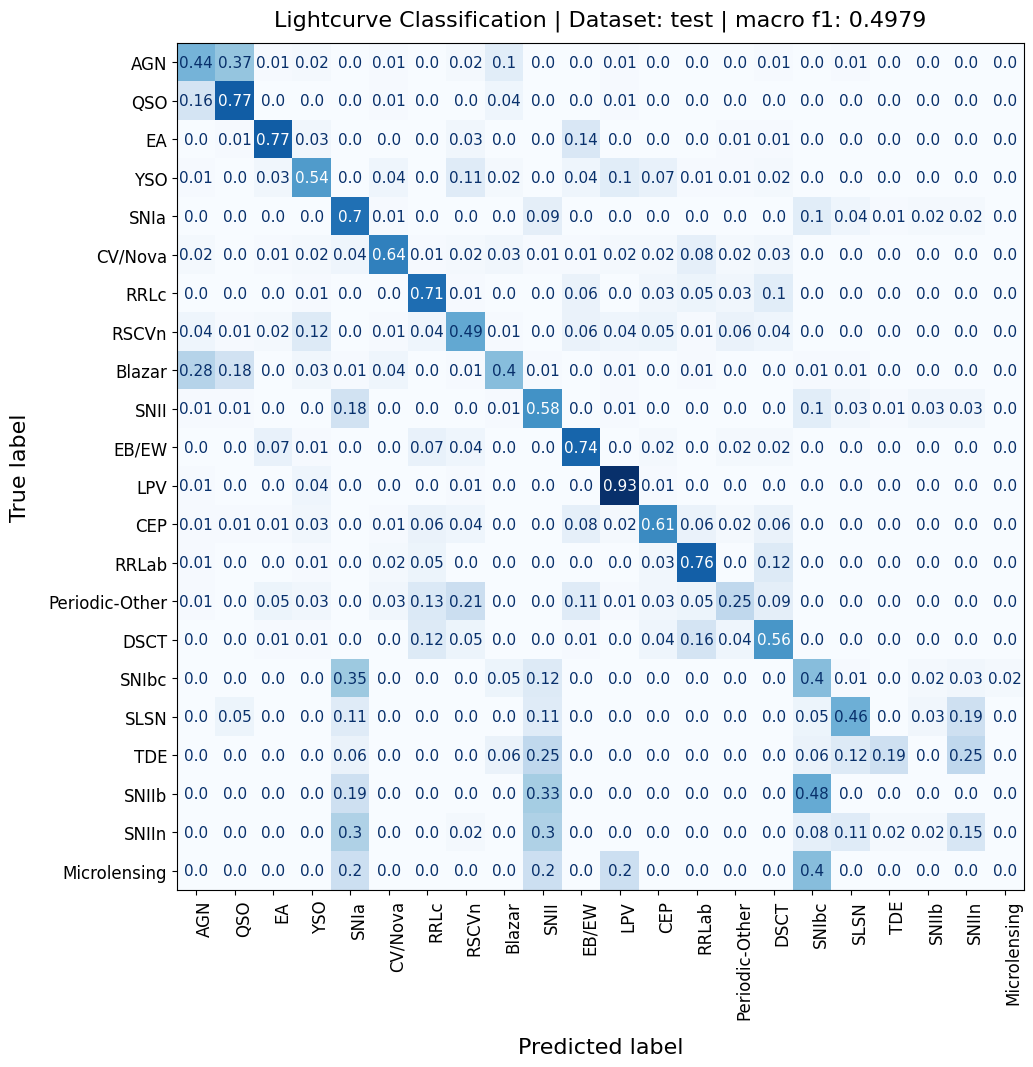

In [11]:
test = InitClassifier(path_to_config_yaml=PATH_1,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False


dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_1 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Lightcurve Classification | Dataset', order_classes=list(ZTF_TAXONOMY().keys()))


In [8]:
import pandas as pd

df = pd.DataFrame({'true':val_true, 'pred':np.argmax(val_preds, axis = -1)})

transient_dict = ZTF_TAXONOMY.transient.group
transients = df.query('true in {}'.format(list(transient_dict.values())))
print(classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=False))

##
stochastic_dict = ZTF_TAXONOMY.stochastic.group
stochastics = df.query('true in {}'.format(list(stochastic_dict.values())))
print(classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=False))
####
periodic_dict = ZTF_TAXONOMY.periodic.group
periodics = df.query('true in {}'.format(list(periodic_dict.values())))
print(classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=False))


sum([classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score']])/3

              precision    recall  f1-score   support

        SNIa     0.7336    0.7381    0.7359       485
        SNII     0.6301    0.5657    0.5962       274
       SNIbc     0.3061    0.3488    0.3261        86
        SLSN     0.2581    0.2162    0.2353        37
         TDE     0.2273    0.3125    0.2632        16
       SNIIb     0.0476    0.0476    0.0476        21
       SNIIn     0.2619    0.2075    0.2316        53
Microlensing     0.0000    0.0000    0.0000         5

   micro avg     0.5973    0.5814    0.5892       977
   macro avg     0.3081    0.3046    0.3045       977
weighted avg     0.5966    0.5814    0.5880       977

              precision    recall  f1-score   support

         AGN     0.5195    0.5504    0.5345       556
         QSO     0.6769    0.6175    0.6459       570
         YSO     0.8857    0.4456    0.5929       487
     CV/Nova     0.8947    0.6375    0.7445       320
      Blazar     0.5532    0.4815    0.5149       270

   micro avg     0.6654

0.52566751119129

True False False
Using checkpoint 7392.ckpt
Using checkpoint 7392.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


100%|██████████| 477/477 [00:05<00:00, 82.48it/s]


                precision    recall  f1-score   support

           AGN     0.5726    0.4892    0.5276       556
           QSO     0.6842    0.6842    0.6842       570
            EA     0.8112    0.8140    0.8126       570
           YSO     0.6255    0.6653    0.6448       487
          SNIa     0.7833    0.5814    0.6675       485
       CV/Nova     0.7003    0.7375    0.7184       320
          RRLc     0.6785    0.7595    0.7167       578
         RSCVn     0.5726    0.4797    0.5221       444
        Blazar     0.4755    0.6111    0.5348       270
          SNII     0.7738    0.4745    0.5882       274
         EB/EW     0.6642    0.7699    0.7131       578
           LPV     0.8835    0.9155    0.8992       580
           CEP     0.7729    0.5654    0.6531       566
         RRLab     0.6911    0.8419    0.7591       582
Periodic-Other     0.3402    0.3417    0.3410       240
          DSCT     0.5489    0.3322    0.4139       304
         SNIbc     0.2800    0.4884    0.3559  

<Axes: title={'center': 'Finetuned Lightcurve Classification | Dataset: test | macro f1: 0.5142'}, xlabel='Predicted label', ylabel='True label'>

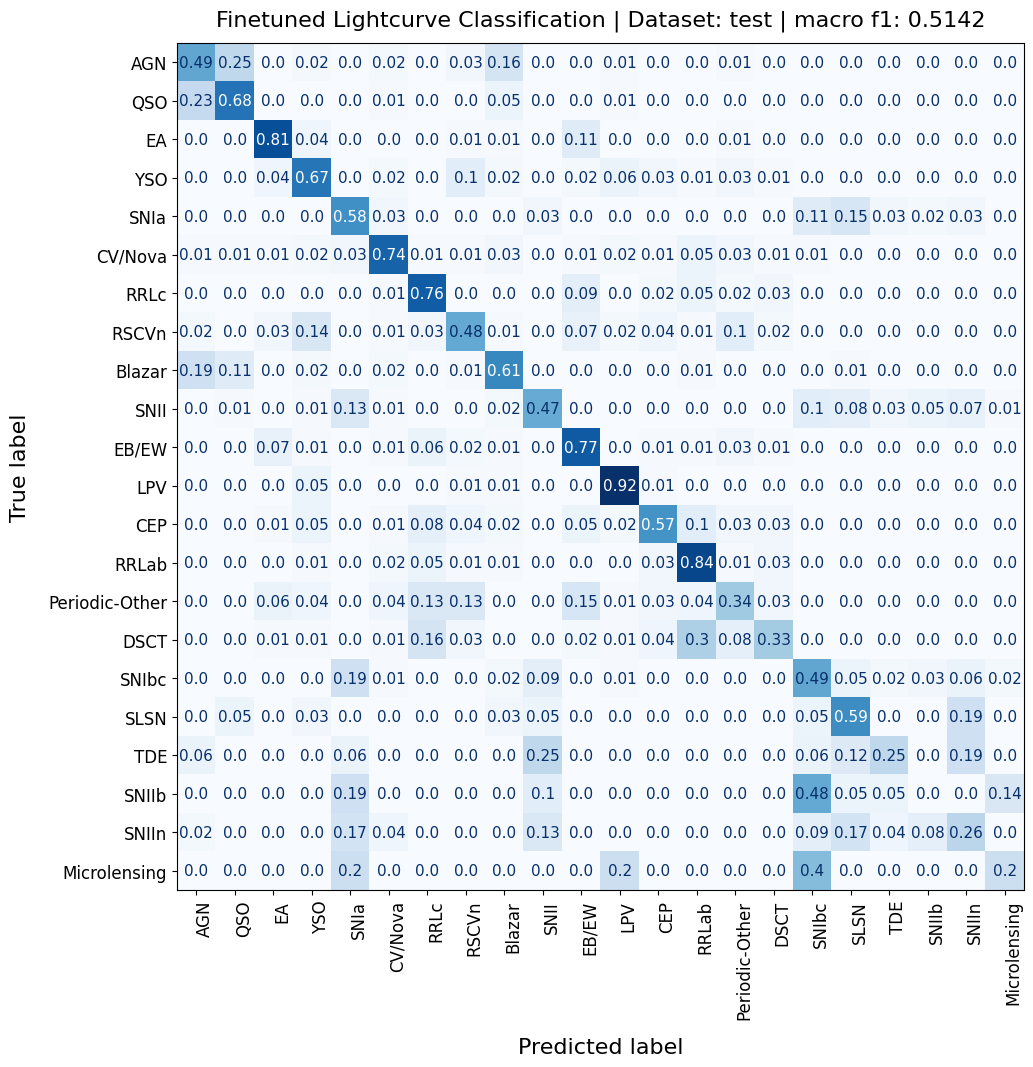

In [8]:
test = InitClassifier(path_to_config_yaml=PATH_2,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_2 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Finetuned Lightcurve Classification | Dataset', order_classes=list(ZTF_TAXONOMY().keys()))


In [21]:
import pandas as pd

df = pd.DataFrame({'true':val_true, 'pred':np.argmax(val_preds, axis = -1)})

transient_dict = ZTF_TAXONOMY.transient.group
transients = df.query('true in {}'.format(list(transient_dict.values())))
print(classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=False))

##
stochastic_dict = ZTF_TAXONOMY.stochastic.group
stochastics = df.query('true in {}'.format(list(stochastic_dict.values())))
print(classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=False))
####
periodic_dict = ZTF_TAXONOMY.periodic.group
periodics = df.query('true in {}'.format(list(periodic_dict.values())))
print(classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=False))


sum([classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score']])/3

              precision    recall  f1-score   support

        SNIa     0.8237    0.5588    0.6658       485
        SNII     0.6907    0.4891    0.5726       274
       SNIbc     0.2549    0.4535    0.3264        86
        SLSN     0.2136    0.5946    0.3143        37
         TDE     0.1500    0.1875    0.1667        16
       SNIIb     0.0000    0.0000    0.0000        21
       SNIIn     0.0986    0.1321    0.1129        53
Microlensing     0.3333    0.4000    0.3636         5

   micro avg     0.5085    0.4893    0.4987       977
   macro avg     0.3206    0.3519    0.3153       977
weighted avg     0.6427    0.4893    0.5425       977

              precision    recall  f1-score   support

         AGN     0.6161    0.4532    0.5223       556
         QSO     0.6734    0.7561    0.7124       570
         YSO     0.9143    0.5914    0.7182       487
     CV/Nova     0.8655    0.7438    0.8000       320
      Blazar     0.5810    0.5444    0.5621       270

   micro avg     0.7167

0.5539141274451151

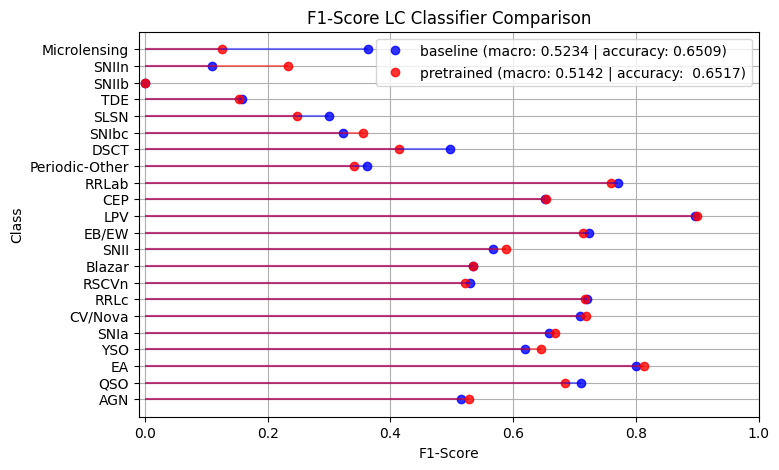

baseline f1 mean:
trans 0.30961288284385446
stoch 0.6173918290009117
per 0.661151886724052
pretrained f1 mean:
trans 0.30299354249847066
stoch 0.6196851932066374
per 0.65451124322303


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
       # print(key,value)
        if key in ZTF_TAXONOMY().keys():

            f1_baseline.append(value['f1-score'])

    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('baseline f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('pretrained f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

In [23]:
t_ = 1

In [ ]:
test = InitClassifier(path_to_config_yaml=PATH_2,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict_by_time(dl.test_dataset, DEVICE,eval_times = [t_]) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)


True False False
Using checkpoint 4848.ckpt
Using checkpoint 4848.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


  0%|          | 0/477 [00:00<?, ?it/s]


In [23]:
import torch

# Example tensor
bsz, seqlen, channels = 2, 5, 3
x = torch.randn(bsz, seqlen, channels)

dt = 0.2

# find min per sample (over seqlen & channels)
min_vals, _ = x.view(bsz, -1).min(dim=1)   # shape [bsz]

# reshape for broadcasting: [bsz, 1, 1]
min_vals = min_vals.view(bsz, 1, 1)

# compute mask
mask = x < (min_vals + dt)

print("x shape:", x)
print("mask shape:", mask)


x shape: tensor([[[ 3.0852e-01, -4.1230e-01, -3.1842e-01],
         [ 8.0920e-04,  4.6384e-02, -5.4418e-01],
         [-7.0441e-01, -7.7820e-01, -9.5111e-01],
         [-5.2094e-01,  7.6540e-02,  1.5215e-01],
         [ 2.2895e+00,  1.1036e+00,  1.2113e+00]],

        [[-4.2369e-02, -7.3361e-02,  6.4931e-01],
         [-3.5681e-01, -2.1312e+00, -2.7035e+00],
         [ 1.0417e-01, -1.2709e+00, -1.2558e+00],
         [-6.2700e-01, -2.2226e+00, -9.7979e-01],
         [ 4.0984e-01, -1.1913e+00, -2.1165e-01]]])
mask shape: tensor([[[False, False, False],
         [False, False, False],
         [False,  True,  True],
         [False, False, False],
         [False, False, False]],

        [[False, False, False],
         [False, False,  True],
         [False, False, False],
         [False, False, False],
         [False, False, False]]])


In [24]:
report_2 = classification_report(val_true, np.argmax(val_preds[t_], axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds[t_], axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds[t_], axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Finetuned Lightcurve Classification | Dataset', order_classes=list(ZTF_TAXONOMY().keys()))


ValueError: attempt to get argmax of an empty sequence